In [3]:
from neuralprophet import NeuralProphet
NeuralProphet()

In [4]:
import sys
import os

# Ajouter la racine du projet au PYTHONPATH
sys.path.append(os.path.abspath("../.."))

import pandas as pd
from src.prediction.time_series import train_prophet, forecast_prophet


# Charger le dataset d'exemple
df = pd.read_csv("../../data/examples/urgences_exemple.csv")

# Convertir la colonne datetime
df["datetime"] = pd.to_datetime(df["datetime"])

# Vérifier la structure
df.head()

,datetime,arrivals
0,2024-01-01 00:00:00,16.0
1,2024-01-01 01:00:00,15.0
2,2024-01-01 02:00:00,16.0
3,2024-01-01 03:00:00,18.0
4,2024-01-01 04:00:00,15.0


In [28]:
import pandas as pd
from neuralprophet import NeuralProphet

def train_prophet(df: pd.DataFrame, date_col: str, target_col: str):
    model_df = df[[date_col, target_col]].rename(columns={date_col: "ds", target_col: "y"})
    model = NeuralProphet()
    model.fit(model_df, freq="H")
    return model

def train_prophet(df, date_col, target_col):
    model_df = df[[date_col, target_col]].rename(columns={date_col: "ds", target_col: "y"})
    model = NeuralProphet()
    model.fit(model_df, freq="H")
    return model, model_df





WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():

WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (N

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (34) is too small than the required number                     for the learning rate finder (233). The results might not be optimal.
Finding best initial lr: 100%|██████████| 233/233 [00:02<00:00, 94.76it/s]


Training: |          | 0/? [00:27<?, ?it/s, v_num=16, train_loss=0.030, reg_loss=0.000, MAE=1.610, RMSE=2.020, Loss=0.0299, RegLoss=0.000] 

WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.954% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1173: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  aux_ts = pd.DataFrame(pd.date_range("1994-01-01", periods=100, freq=freq_str))

WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype


Predicting DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 166.66it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


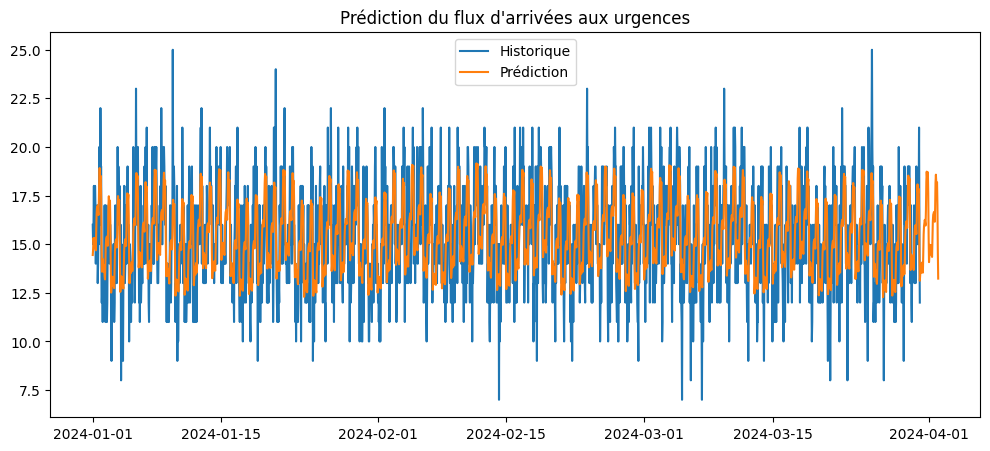

In [ ]:
import matplotlib.pyplot as plt

model, model_df = train_prophet(df, "datetime", "arrivals")
forecast = forecast_prophet(model, model_df, periods=48)
#forecast.head()
#forecast.columns

plt.figure(figsize=(12, 5))
plt.plot(df["datetime"], df["arrivals"], label="Historique")
plt.plot(forecast["ds"], forecast["yhat1"], label="Prédiction")
plt.legend()
plt.title("Prédiction du flux d'arrivées aux urgences")
plt.show()


In [42]:
import numpy as np
import pandas as pd

mu = 20.0  # à ajuster selon ta réalité

# On part de ton forecast existant
mm1 = forecast.copy()
mm1["lambda"] = mm1["yhat1"]          # arrivées prédites par heure
mm1["rho"] = mm1["lambda"] / mu       # taux d'occupation

# On force la stabilité : on ignore (ou marque) les heures où lambda >= mu
mm1["stable"] = mm1["lambda"] < mu

# Formules M/M/1 (là où c'est stable)
mm1.loc[mm1["stable"], "Lq"] = (mm1["rho"]**2 / (1 - mm1["rho"]))[mm1["stable"]]
mm1.loc[mm1["stable"], "L"]  = (mm1["rho"] / (1 - mm1["rho"]))[mm1["stable"]]
mm1.loc[mm1["stable"], "Wq"] = mm1["Lq"][mm1["stable"]] / mm1["lambda"][mm1["stable"]]
mm1.loc[mm1["stable"], "W"]  = mm1["L"][mm1["stable"]]  / mm1["lambda"][mm1["stable"]]

In [43]:
mm1["stable"].value_counts()

stable
True    2209
Name: count, dtype: int64

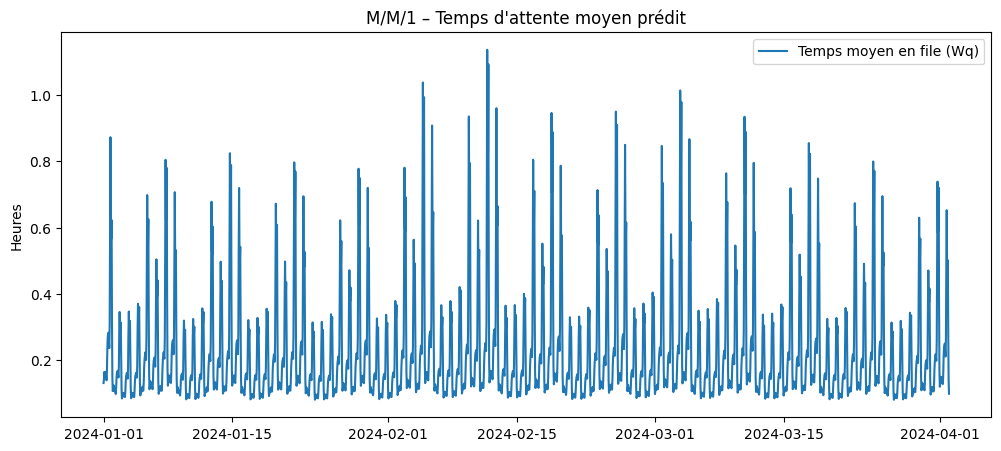

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(mm1["ds"], mm1["Wq"], label="Temps moyen en file (Wq)")
plt.ylabel("Heures")
plt.legend()
plt.title("M/M/1 – Temps d'attente moyen prédit")
plt.show()

In [45]:
import numpy as np
import pandas as pd

mu_doc = 3.3  # patients/heure par médecin (estimé)
c_values = [3, 4, 5, 6, 7]  # scénarios de nombre de médecins

lambda_t = forecast["yhat1"].values  # arrivées prédites par heure
ds = forecast["ds"].values

def mmc_metrics(lmbda, mu_doc, c):
    mu_tot = c * mu_doc
    rho = lmbda / mu_tot  # taux d'occupation global

    if lmbda == 0:
        return rho, 0.0  # pas d'arrivées, pas d'attente

    a = lmbda / mu_doc  # charge offerte

    # Calcul de P0 (probabilité que le système soit vide)
    sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))
    last_term = (a**c) / (np.math.factorial(c) * (1 - rho)) if rho < 1 else np.inf

    if rho >= 1:
        return rho, np.inf  # système instable

    P0 = 1.0 / (sum_terms + last_term)

    # Probabilité qu'un patient attende (Erlang C)
    Pc = (a**c / (np.math.factorial(c) * (1 - rho))) * P0

    # Temps moyen en file (Wq)
    Wq = Pc / (c * mu_doc - lmbda)  # en heures

    return rho, Wq

# On construit un DataFrame avec un Wq par scénario de c
mmc = pd.DataFrame({"ds": ds, "lambda": lambda_t})

for c in c_values:
    rhos = []
    wqs = []
    for lmbda in lambda_t:
        rho, Wq = mmc_metrics(lmbda, mu_doc, c)
        rhos.append(rho)
        wqs.append(Wq)
    mmc[f"rho_c{c}"] = rhos
    mmc[f"Wq_c{c}"] = wqs


WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_25680\3328086401.py:20: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_25680\3328086401.py:20: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  sum_terms = sum((a**k) / np.math.factorial(k) for k in range(c))

WARNING - (py.warnings._showwarnmsg) - C:\Users\jonat\AppData\Local\Temp\ipykernel_25680\3328086401.py:21: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  last_term = (a**c) / (np.math.factorial(c) * (1 - rho)) if rho < 1 else n

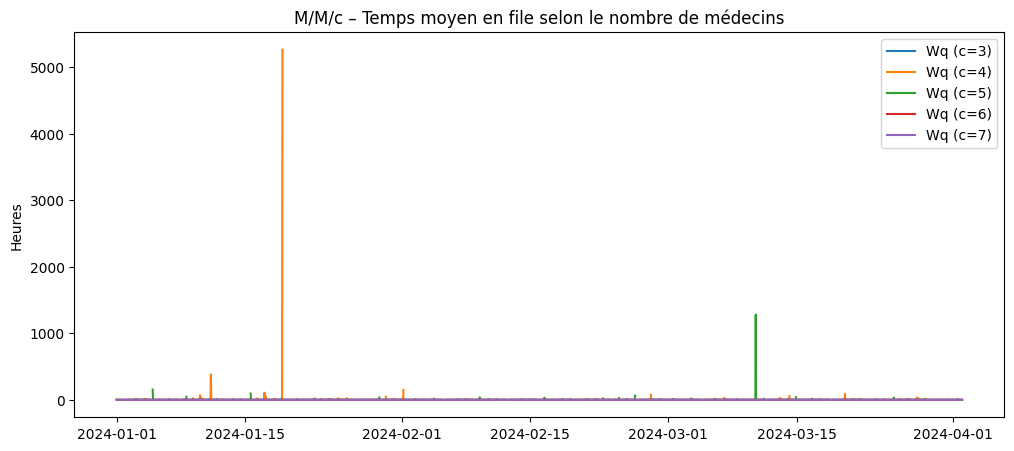

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
for c in c_values:
    plt.plot(mmc["ds"], mmc[f"Wq_c{c}"], label=f"Wq (c={c})")
plt.ylabel("Heures")
plt.title("M/M/c – Temps moyen en file selon le nombre de médecins")
plt.legend()
plt.show()